In [15]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd

from keras_yamnet import params
from keras_yamnet.yamnet import YAMNet
import keras_yamnet.preprocessing as kp
from keras_yamnet.postprocessing import postprocess_output

import tensorflow as tf

import soundfile as sf
import os
import platform
import time
from tqdm import tqdm
import pickle
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
import h5py
from sklearn.utils import shuffle
from sed_eval.sound_event import EventBasedMetrics, SegmentBasedMetrics
from dataset import gt_conversion_functions as cf
import settings
import importlib
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D
importlib.reload(settings)

# print("CUDA available:", torch.cuda.is_available())  # should be True
# print("Wheel CUDA runtime:", torch.version.cuda)     # should be '11.8'
# print("GPU:", torch.cuda.get_device_name(0))

<module 'settings' from '/Users/ingeborgborhaug/Skole/9.semester (harddrive)/Prosjektoppgave/sound-event-detection-aircrafts/settings.py'>

In [43]:
# Functions and Classes

class ModifiedModel(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 512)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(512, num_classes)
        # self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        # x = self.sigmoid(x)
        return x
    
def save_arrays_to_cache(x, y, cache_file):
    with h5py.File(cache_file, 'w') as f:
        dset_x = f.create_dataset('x', shape=x.shape, dtype=x.dtype)
        dset_y = f.create_dataset('y', shape=y.shape, dtype=y.dtype)
        for i in tqdm(range(x.shape[0]), desc='Saving x to cache'):
            dset_x[i] = x[i]
        for i in tqdm(range(y.shape[0]), desc='Saving y to cache'):
            dset_y[i] = y[i]

def load_arrays_from_cache(cache_file):
    with h5py.File(cache_file, 'r') as f:
        x = f['x'][:]
        y = f['y'][:]
    return x, y

def load_features_and_labels_from_cache(gt_paths, audios_folders, base_model, force_reload, apply_filter):

    if apply_filter == None:
        filter_name = 'Unfiltered'
    else:
        filter_name = apply_filter

    if isinstance(gt_paths, tuple):
        name = ''
        for gt_path in gt_paths:              
            base = os.path.basename(gt_path) 
            gt_name, _ = os.path.splitext(base)  
            name += gt_name + '_'

        name = name.rstrip('_')
        cache_file = os.path.dirname(gt_path) + f'{name}_{filter_name}.npz'
    else:
        cache_file = os.path.splitext(gt_paths)[0] + f'_{filter_name}' + '.npz'

    if os.path.exists(cache_file) and not force_reload:
        print(f"Loading cached result from {cache_file} ...")
        x, y = load_arrays_from_cache(cache_file)
    else:
        print(f'Processing and caching in : {cache_file}')
        x, y = load_features_and_array_labels(gt_paths, audios_folders, base_model, apply_filter=apply_filter)
        save_arrays_to_cache(x, y, cache_file)

    return x, y


def load_features_and_array_labels(gt_paths, audio_folders, base_model, apply_filter):
    """
    Load training data from ground truth file and preprocess it.

    Args:
        gt_file (pd.DataFrame): DataFrame containing ground truth data.
    Returns:
        input_array (np.ndarray): Array of preprocessed audio data patches.
        output_array (np.ndarray): Array of target outputs corresponding to the audio data. 
            Contains targets that are one-hot encoded vectors for each class.
    """

    class_to_count = [0 for _ in range(settings.N_CLASSES)]
    n_detections = 0

    audiofile_to_detection1 = {}  
    audiofile_to_patches1 = {}  
    audiofile_to_detection2 = {}  
    audiofile_to_patches2 = {} 

    # Check for tuple or string input for gt_paths
    if isinstance(gt_paths, tuple):
        gt_path1, gt_path2 = gt_paths
    elif isinstance(gt_paths, str):
        gt_path1 = gt_paths
        gt_path2 = None
    else:
        raise KeyError(f'The instance of gt_paths in dictionary with key {gt_paths} is not proper.')
    
    gt_file1 = pd.read_csv(gt_path1, sep='\s+')
    
    # Handle for two ground truth files 
    if gt_path2 is not None:
        gt_file2 = pd.read_csv(gt_path2, sep='\s+') 

        for (idx1, row1), (idx2, row2) in zip(gt_file1.iterrows(), gt_file2.iterrows()):

            if row1['start_time'] != row2['start_time'] or row1['end_time'] != row2['end_time'] or row1['class'] != row2['class']:
                raise ValueError(f'Ground truth files {gt_path1} and {gt_path2} do not match at rows {idx1} and {idx2}.')
            
            audiofile1 = row1['filename']
            audiofile2 = row2['filename']
            starttime = row1['start_time']
            endtime = row1['end_time']
            class_idx = row1['class']

            patch_index_start = cf.second_to_index(starttime)
            patch_index_end = cf.second_to_index(endtime)

            class_to_count[class_idx] += 1
            n_detections += 1

            if audiofile1 not in audiofile_to_detection1:

                audio_path1 = find_file_in_folder(audio_folders, audiofile1)
                audio_path2 = find_file_in_folder(audio_folders, audiofile2)

                audio_wave1, sample_rate1 = sf.read(audio_path1)
                audio_wave2, sample_rate2 = sf.read(audio_path2)

                data_patches1, _ , data_patches2, _ = kp.preprocess_input(
                    waveform1=audio_wave1, 
                    waveform2=audio_wave2, 
                    sr1=sample_rate1, 
                    sr2=sample_rate2,
                    apply_filter=apply_filter)
                
                audiofile_to_patches1[audiofile1] = data_patches1
                audiofile_to_patches2[audiofile2] = data_patches2

                pred = np.zeros((len(data_patches1), settings.N_CLASSES), dtype=np.float32)
                pred[patch_index_start:patch_index_end+1, class_idx] = settings.GT_CONFIDENCE
                audiofile_to_detection1[audiofile1] = pred
                audiofile_to_detection2[audiofile2] = pred
            else:
                audiofile_to_detection1[audiofile1][patch_index_start:patch_index_end, class_idx] = settings.GT_CONFIDENCE
                audiofile_to_detection2[audiofile2][patch_index_start:patch_index_end, class_idx] = settings.GT_CONFIDENCE

    # Handle for single ground truth file
    if gt_path2 is None:
        if apply_filter == 'ica':
            raise ValueError('ICA filtering requires two ground truth files.')
        
        for _, row in tqdm(gt_file1.iterrows(), total=len(gt_file1), desc='Loading gt'):

            audiofile = row['filename']
            starttime = row['start_time']
            endtime = row['end_time']
            class_idx = row['class']

            patch_index_start = cf.second_to_index(starttime)
            patch_index_end = cf.second_to_index(endtime)

            class_to_count[class_idx] += 1
            n_detections += 1

            if audiofile not in audiofile_to_detection1:

                audio_path = find_file_in_folder(audio_folders, audiofile)

                audio_wave, sample_rate = sf.read(audio_path)
                data_patches, _ = kp.preprocess_input(audio_wave, sample_rate, apply_filter=apply_filter)
                audiofile_to_patches1[audiofile] = data_patches

                pred = np.zeros((len(data_patches), settings.N_CLASSES), dtype=np.float32)
                pred[patch_index_start:patch_index_end+1, class_idx] = settings.GT_CONFIDENCE
                audiofile_to_detection1[audiofile] = pred

            else:
                audiofile_to_detection1[audiofile][patch_index_start:patch_index_end, class_idx] = settings.GT_CONFIDENCE

    X_ch1 = []
    y1 = []
    X_ch2 = []
    y2 = []

    for audiofile1 in audiofile_to_detection1.keys(): 
        data_patches1 = audiofile_to_patches1[audiofile1]
        pred1 = audiofile_to_detection1[audiofile1]

        X_ch1.append(data_patches1)
        y1.append(pred1)

    X_ch1 = np.concatenate(X_ch1, axis=0)  # shape: (num_patches, PATCH_FRAMES, n_bands)
    y1 = np.concatenate(y1, axis=0)  # shape: (num_patches, N_CLASSES)

    for audiofile2 in audiofile_to_detection2.keys(): 
        data_patches2 = audiofile_to_patches2[audiofile2]
        pred2 = audiofile_to_detection2[audiofile2]

        X_ch2.append(data_patches2)
        y2.append(pred2)
    
    if X_ch2:
        X_ch2 = np.concatenate(X_ch2, axis=0)  # shape: (num_patches, PATCH_FRAMES, n_bands)
        y2 = np.concatenate(y2, axis=0)  # shape: (num_patches, N_CLASSES)
    else:
        X_ch2 = None
        y2 = None

    if X_ch2 is not None:
        input_embedding1 = base_model.predict(X_ch1, verbose=1) # If keras model
        input_embedding2 = base_model.predict(X_ch2, verbose=1) # If keras model
        X_multi = np.stack([input_embedding1, input_embedding2], axis=1)
    else:
        input_embedding1 = base_model.predict(X_ch1, verbose=1) # If keras model
        X_multi = np.stack([input_embedding1, input_embedding1], axis=1)

    print(f'Percentage class 1 (Aircraft): {class_to_count[1]/(n_detections)}')

    return X_multi, y1

def find_file_in_folder(folder, filename):
    audio_path = None
    for audio_folder in folder:
        candidate = os.path.join(audio_folder, filename)
        if os.path.exists(candidate):
            audio_path = candidate
            break

    if audio_path is None:
        raise FileNotFoundError(f'Audio file {filename} not found in any of the specified folders.')
    
    return audio_path

def visualize_and_save_history(history, timestamp):
    """
    Visualize training history.
    
    Args:
        history (tf.keras.callbacks.History): History object containing training metrics.
    """

    fig, axs = plt.subplots(2, 1, figsize=(12, 10))

    # Loss subplot
    axs[0].plot(history.history['loss'], label='Training Loss', color='#003366')  # Dark blue
    axs[0].plot(history.history['val_loss'], label='Validation Loss', color='#66b3ff')  # Light blue
    axs[0].set_title('Training and Validation Loss')
    axs[0].set_xlabel('Epochs')
    axs[0].set_ylabel('Loss')
    axs[0].set_ylim(0, 1.5)
    axs[0].legend()
    axs[0].grid()

    # F1-SCORE  subplot
    axs[1].plot(history.history['f1_score'], label='Training f1-score', color='#006400')  # Dark green
    axs[1].plot(history.history['val_f1_score'], label='Validation f1-score', color='#90ee90')  # Light green
    axs[1].set_title('Training and Validation f1-score')
    axs[1].set_xlabel('Epochs')
    axs[1].set_ylabel('f1-score')
    axs[1].set_ylim(0, 1)
    axs[1].legend()
    axs[1].grid()

    plt.tight_layout()
    plt.show()

    os.makedirs('history', exist_ok=True)
    os.makedirs(f'history/{timestamp}', exist_ok=True)
    fig.savefig(f'history/{timestamp}/history.png')

def predictions_to_event_list(predictions):
    """
    Convert model predictions to a list of detected events compatible with sed_eval.
    Assumes predictions are binary (0 or 1) for each class at each segment.
    """
    output = []
    predictions = np.array(predictions)
    num_segments, num_classes = predictions.shape

    for i in range(num_segments):
        for class_idx, score in enumerate(predictions[i]):
            if score == 1:
                output.append({
                    'file': 'an_audio',
                    'event_label': settings.CLASS_NAMES[class_idx],
                    'onset': i * params.PATCH_WINDOW_SECONDS,
                    'offset': (i + 1) * params.PATCH_WINDOW_SECONDS
                })

    return output

def print_metrics(metrics, title):
    print(f"\n{title}")
    overall = metrics['overall']
    print(f"  F1: {overall['f_measure']['f_measure']:.3f} | Precision: {overall['f_measure']['precision']:.3f} | Recall: {overall['f_measure']['recall']:.3f}")
    print(f"  Error Rate: {overall['error_rate']['error_rate']:.3f}")
    if 'accuracy' in overall and overall['accuracy']:
        acc = overall['accuracy'].get('accuracy', None)
        if acc is not None:
            print(f"  Accuracy: {acc:.3f}")
    print("  Class-wise F1:")
    for cls, vals in metrics['class_wise'].items():
        f1 = vals['f_measure']['f_measure']
        print(f"    {cls}: {f1:.3f}")

def get_data_from_dict(data_dict, base_model, force_reload= settings.FORCE_RELOAD_TRAIN, apply_filter=None):
    X = None
    y = None

    for gt_paths, audios_folders in data_dict.items():

        X_temp, y_temp = load_features_and_labels_from_cache(gt_paths, audios_folders, base_model, force_reload, apply_filter=apply_filter)
        
        if X is None and y is None:
            X = X_temp
            y = y_temp
        else:
            X = np.concatenate((X, X_temp), axis=0)
            y = np.concatenate((y, y_temp), axis=0)

    X, y = shuffle(X, y, random_state=42)

    N, C, F = X.shape # X_embeddings.shape : (samples, channels, input) = (1904, 2, 1024) 
    X_flat = X.reshape(N, C * F)   # (N, C*F)

    return X_flat, y

def get_device():
    # 1) NVIDIA GPU (Windows/Linux/macOS w/ eGPU): fastest if available
    if torch.cuda.is_available():
        return torch.device("cuda"), "cuda"

    # 2) Apple Silicon GPU (macOS M1/M2/M3)
    if platform.system() == "Darwin" and torch.backends.mps.is_available():
        # Optional: allow silent CPU fallback for unsupported ops on MPS
        os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")
        return torch.device("mps"), "mps"

    # 3) DirectML (Windows + AMD/Intel/NVIDIA via the 'torch-directml' package)
    #    pip install torch-directml   (import torch_directml)  -> a separate package
    try:
        if platform.system() == "Windows":
            import torch_directml  # noqa: F401
            dml = torch_directml.device()
            return dml, "directml"
    except Exception:
        pass

    # 4) CPU fallback (works everywhere)
    return torch.device("cpu"), "cpu"

def save_sed_metric(filename, metric, timestr):
    with open(f'history/{timestr}/{filename}.pk1', "wb") as f:
        pickle.dump(metric, f)

def load_sed_metric(filepath):
    with open(filepath, "rb") as f:
        metric = pickle.load(f)
    return metric

def train_model(X_embedding, y_embedding, model, device, title=None, save=True, val_split=0.2):
    
    # Prepare PyTorch datasets and loaders
    X_tensor = torch.tensor(X_embedding, dtype=torch.float32).to(device)
    y_tensor = torch.tensor(y_embedding, dtype=torch.float32).to(device)
    # dataset = torch.utils.data.TensorDataset(X_tensor, y_tensor)
    # train_loader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=True)

    # Validation split
    val_split = getattr(settings, "VAL_SIZE", val_split)
    num_val = int(len(X_tensor) * val_split)
    indices = np.arange(len(X_tensor.cpu()))
    np.random.shuffle(indices)
    val_indices = indices[:num_val]
    train_indices = indices[num_val:]

    X_val_tensor = X_tensor[val_indices]
    y_val_tensor = y_tensor[val_indices]
    val_dataset = torch.utils.data.TensorDataset(X_val_tensor, y_val_tensor)
    val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=64, shuffle=False)

    X_train_tensor = X_tensor[train_indices]
    y_train_tensor = y_tensor[train_indices]
    train_dataset = torch.utils.data.TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=False)

    #criterion = nn.BCELoss()
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    num_epochs = 300
    patience = 30
    best_loss = float('inf')
    epochs_no_improve = 0
    best_state = None
    train_losses, val_losses = [], []

    for epoch in range(num_epochs):
        model.train(True)
        running_loss = 0.0
        for inputs, targets in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
        epoch_loss = running_loss / len(train_loader.dataset)
        train_losses.append(epoch_loss)

        # Validation
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for inputs, targets in val_loader:
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                val_loss += loss.item() * inputs.size(0)
        val_loss /= len(val_loader.dataset)
        val_losses.append(val_loss)
        print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {epoch_loss:.4f} | Val Loss: {val_loss:.4f}")

        # Early stopping
        if val_loss < best_loss:
            best_loss = val_loss
            best_state = model.state_dict()
            best_epoch = epoch
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print("Early stopping triggered.")
                break

    model.load_state_dict(best_state)

    timestr = time.strftime("%Y%m%d-%H%M%S")
    

    # SAVE MODEL AND LOSS PLOT
    if save:
    
        os.makedirs('history', exist_ok=True)
        os.makedirs(f'history/{timestr}', exist_ok=True)
        torch.save(model, f'history/{timestr}/modified_model_{best_epoch}.pt')

        print(f'Model saved to history/{timestr}/modified_model_{best_epoch}.pt')
        
        plt.plot(train_losses, label='Train Loss')
        plt.plot(val_losses, label='Val Loss')
        plt.legend()
        plt.title(title)
        pdf_path = f'history/{timestr}/loss_plot.pdf'
        plt.savefig(pdf_path, format='pdf', bbox_inches='tight')
        print(f'Saved loss plot in vector PDF: {pdf_path}')

    return model, train_losses, val_losses

def plot_losses_discrete(losses_by_snr, title="Loss per Epoch (discrete SNR colors)", save_path=None, snrs=None, max_epochs=None, y_lim=100):
    fig, ax = plt.subplots(figsize=(10, 6))
    snrs = sorted(losses_by_snr.keys())
    cmap_name = "Reds"
    cmap = plt.cm.RdYlGn
    norm = Normalize(vmin=min(snrs), vmax=max(snrs))
    color_for = {snr: cmap(norm(snr)) for snr in snrs}

    for snr, (train_losses, val_losses) in sorted(losses_by_snr.items()):
        if max_epochs:
            train_losses = train_losses[:max_epochs]
            val_losses = val_losses[:max_epochs]
        c = color_for.get(snr, "k")
        xt = np.arange(1, len(train_losses) + 1)
        xv = np.arange(1, len(val_losses) + 1)
        ax.plot(xt, train_losses, color=c, linewidth=0.5)
        ax.plot(xv, val_losses,  color=c, linestyle="--", linewidth=0.5)

    # plt.axhline(y=0.1395, color='b', linestyle='-')
    # plt.axhline(y=0.1136, color='tab:orange', linestyle='-')
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, y_lim)

    # Legend 1: color ↔ SNR (inside the plot)
    color_handles = [Line2D([0], [0], color=color_for[s], lw=3, label=f"SNR {s}") for s in sorted(losses_by_snr)]
    leg1 = ax.legend(handles=color_handles, loc="upper right", frameon=True, title="SNR")
    ax.add_artist(leg1)

    # Legend 2: line style (train vs val)
    style_handles = [
        Line2D([0], [0], color="black", linestyle="-",  label="Train"),
        Line2D([0], [0], color="black", linestyle="--", label="Validation"),
    ]
    leg_style = ax.legend(handles=style_handles, loc="lower right", frameon=True, title="Line style")
    ax.add_artist(leg_style)

    # # Legend 3: baseline model loss
    # model_handles = [
    #     Line2D([0], [0], color="b",  label="Train"),
    #     Line2D([0], [0], color="tab:orange", label="Validation"),
    # ]
    # leg_model = ax.legend(handles=model_handles, loc="upper left", frameon=True, title="Baseline model preformance")
    # ax.add_artist(leg_model)
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
        print("Saved:", save_path)
    else:
        plt.show()

    

In [4]:
# Load baseline model

yamnet_model_name = 'keras_yamnet/yamnet.h5'
yamnet_model = YAMNet(weights=yamnet_model_name)
base_model = tf.keras.Model(
    inputs=yamnet_model.input,
    outputs=yamnet_model.get_layer('global_average_pooling2d').output
)
yamnet_model.trainable = False
base_model.trainable = False

In [ ]:
# Load dataset
importlib.reload(settings) 


X_embeddings_env, y_env = get_data_from_dict(settings.data_pair_env, base_model, force_reload=False)
X_embeddings_train, y_train = get_data_from_dict(settings.data_pairs_train, base_model, force_reload=False)
X_embeddings_test, y_test = get_data_from_dict(settings.data_pairs_test, base_model, force_reload=False)

Loading cached result from /Users/ingeborgborhaug/Skole/9.semester (harddrive)/Prosjektoppgave/sound-event-detection-aircrafts/dataset/AeroSonicDB/env_audio_gt_Unfiltered.npz ...
Processing and caching in : /Users/ingeborgborhaug/Skole/9.semester (harddrive)/Prosjektoppgave/sound-event-detection-aircrafts/dataset/AeroSonicDB/gt_train_Unfiltered.npz


Loading gt: 100%|██████████| 1479/1479 [00:37<00:00, 39.10it/s]


Percentage class 1 (Aircraft): 0.3556457065584855
4878/4878 [==============================] - 119s 24ms/step


Saving y to cache: 100%|██████████| 156092/156092 [00:03<00:00, 51952.96it/s]


Processing and caching in : /Users/ingeborgborhaug/Skole/9.semester (harddrive)/Prosjektoppgave/sound-event-detection-aircrafts/dataset/AeroSonicDB/gt_test_Unfiltered.npz


Loading gt: 100%|██████████| 416/416 [00:07<00:00, 54.50it/s]


Percentage class 1 (Aircraft): 0.23798076923076922
1087/1087 [==============================] - 29s 27ms/step


Saving y to cache: 100%|██████████| 34776/34776 [00:00<00:00, 52437.24it/s]


Using device: mps
Epoch 1/300 | Train Loss: 0.3813 | Val Loss: 0.3229
Epoch 2/300 | Train Loss: 0.3395 | Val Loss: 0.3256
Epoch 3/300 | Train Loss: 0.3316 | Val Loss: 0.2991
Epoch 4/300 | Train Loss: 0.3187 | Val Loss: 0.2897
Epoch 5/300 | Train Loss: 0.3045 | Val Loss: 0.2806
Epoch 6/300 | Train Loss: 0.2968 | Val Loss: 0.2753
Epoch 7/300 | Train Loss: 0.2919 | Val Loss: 0.2767
Epoch 8/300 | Train Loss: 0.2861 | Val Loss: 0.2736
Epoch 9/300 | Train Loss: 0.2818 | Val Loss: 0.2723
Epoch 10/300 | Train Loss: 0.2783 | Val Loss: 0.2741
Epoch 11/300 | Train Loss: 0.2725 | Val Loss: 0.2703
Epoch 12/300 | Train Loss: 0.2694 | Val Loss: 0.2636
Epoch 13/300 | Train Loss: 0.2630 | Val Loss: 0.2705
Epoch 14/300 | Train Loss: 0.2605 | Val Loss: 0.2620
Epoch 15/300 | Train Loss: 0.2575 | Val Loss: 0.2889
Epoch 16/300 | Train Loss: 0.2543 | Val Loss: 0.2595
Epoch 17/300 | Train Loss: 0.2525 | Val Loss: 0.2707
Epoch 18/300 | Train Loss: 0.2489 | Val Loss: 0.2644
Epoch 19/300 | Train Loss: 0.2454 | V

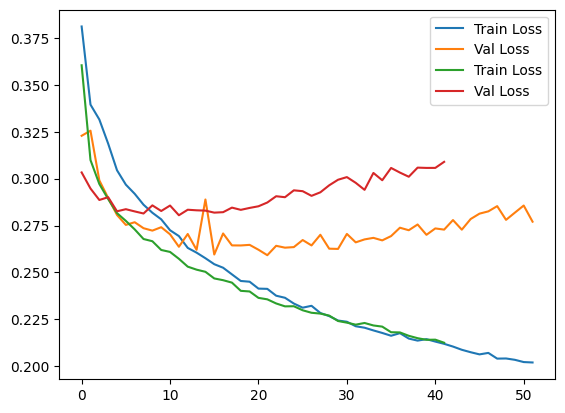

In [9]:
# Load data and train the model

if __name__ == "__main__":

    device, device_type = get_device()
    print(f"Using device: {device_type}")
    
    model = ModifiedModel(input_dim=2048, num_classes=settings.N_CLASSES).to(device)

    trained_model , _, _ = train_model(X_embeddings_train, y_train, model, device, save=True)
    trained_model_2, _, _ = train_model(X_embeddings_env, y_env, trained_model, device, save=True)


In [12]:
# Load model

path = "history/20251117-005332/modified_model_21.pt"  
device, _ = get_device()
synthetic_data_folder = "dataset/synthetic_data/part1"

model = torch.load(path, map_location=device, weights_only=False)

Processing and caching in : dataset/synthetic_data/part1/snr_1_gt_Unfiltered.npz


Loading gt:   0%|          | 0/12 [00:00<?, ?it/s]

Loading gt: 100%|██████████| 12/12 [00:00<00:00, 23.04it/s]


Percentage class 1 (Aircraft): 0.3333333333333333
60/60 [==============================] - 2s 33ms/step


Saving y to cache: 100%|██████████| 1904/1904 [00:00<00:00, 49869.52it/s]


...

Loading gt: 100%|██████████| 12/12 [00:00<00:00, 16.78it/s]


Percentage class 1 (Aircraft): 0.3333333333333333
60/60 [==============================] - 2s 38ms/step


Saving y to cache: 100%|██████████| 1904/1904 [00:00<00:00, 49216.72it/s]

X_embeddings_mix_snr20_bp.shape : (1904, 2048)


Epoch 1/300 | Train Loss: 2.7211 | Val Loss: 0.8143
Epoch 2/300 | Train Loss: 0.7398 | Val Loss: 0.7583
Epoch 3/300 | Train Loss: 0.7334 | Val Loss: 0.7430
Epoch 4/300 | Train Loss: 0.7545 | Val Loss: 0.7302
Epoch 5/300 | Train Loss: 0.7140 | Val Loss: 0.7112
Epoch 6/300 | Train Loss: 0.7142 | Val Loss: 0.6956
Epoch 7/300 | Train Loss: 0.6839 | Val Loss: 0.6908
Epoch 8/300 | Train Loss: 0.6875 | Val Loss: 0.6881
Epoch 9/300 | Train Loss: 0.6742 | Val Loss: 0.6848
Epoch 10/300 | Train Loss: 0.6711 | Val Loss: 0.6742
Epoch 11/300 | Train Loss: 0.6647 | Val Loss: 0.6715
Epoch 12/300 | Train Loss: 0.6783 | Val Loss: 0.6800
Epoch 13/300 | Train Loss: 0.6800 | Val Loss: 0.6688
Epoch 14/300 | Train Loss: 0.6727 | Val Loss: 0.6708
Epoch 15/300 | Train Loss: 0.6715 | Val Loss: 0.6671
Epoch 16/300 | Train Loss: 0.6653 | Val Loss: 0.6667
Epoch 17/300 | Train Loss: 0.6731 | Val Loss: 0.6731
Epoch 18/300 | Train Loss: 0.6770 | Val Loss: 0.6731
Epoch 19/300 | Train Loss: 0.6611 | Val Loss: 0.6689
Ep

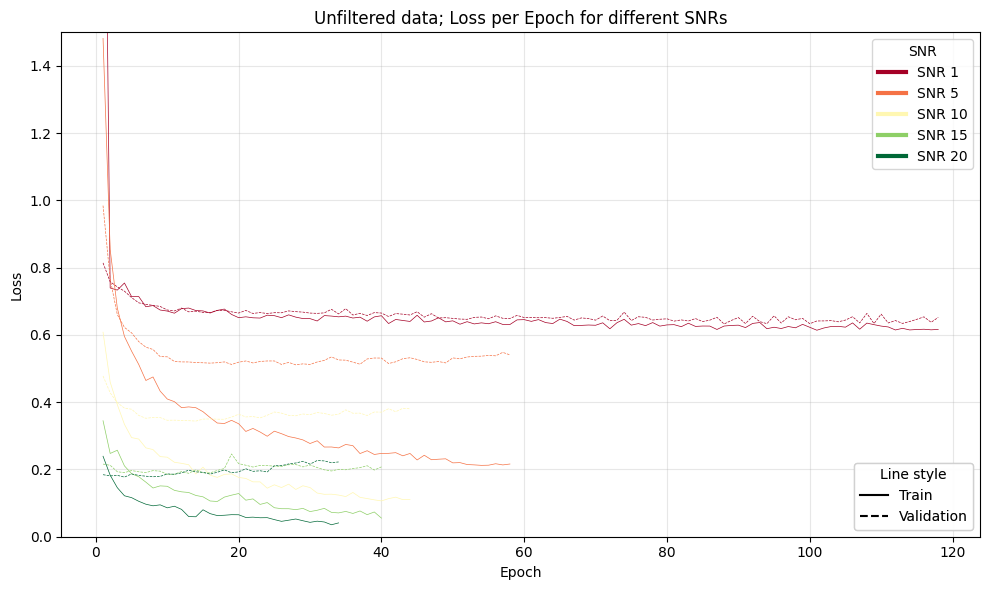

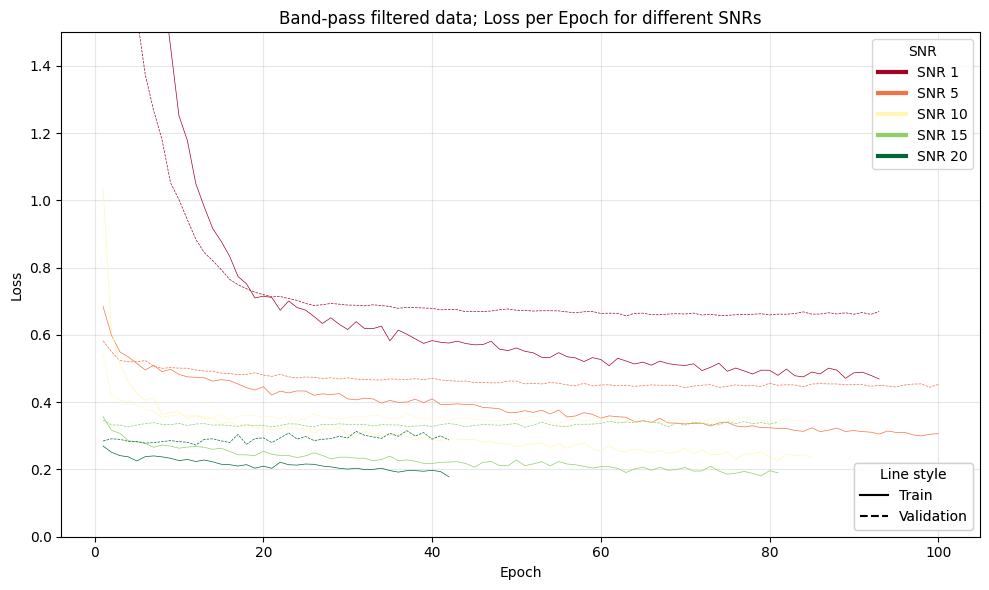

In [ ]:
# Part 1: One channel

# Load unfiltered data
importlib.reload(settings) 
importlib.reload(kp)
 
X_embeddings_snr1, y_snr1 = get_data_from_dict(settings.data_pair1_snr1, base_model, force_reload=True)
X_embeddings_snr5, y_snr5 = get_data_from_dict(settings.data_pair1_snr5, base_model, force_reload=True)
X_embeddings_snr10, y_snr10 = get_data_from_dict(settings.data_pair1_snr10, base_model, force_reload=True)
X_embeddings_snr15, y_snr15 = get_data_from_dict(settings.data_pair1_snr15, base_model, force_reload=True)
X_embeddings_snr20, y_snr20 = get_data_from_dict(settings.data_pair1_snr20, base_model, force_reload=True)

# Load band-pass filtered data
X_embeddings_snr1_bp, y_snr1_bp = get_data_from_dict(settings.data_pair1_snr1, base_model, force_reload= True, apply_filter="bandpass")
X_embeddings_snr5_bp, y_snr5_bp = get_data_from_dict(settings.data_pair1_snr5, base_model, force_reload= True, apply_filter="bandpass")
X_embeddings_snr10_bp, y_snr10_bp = get_data_from_dict(settings.data_pair1_snr10, base_model, force_reload= True, apply_filter="bandpass")
X_embeddings_snr15_bp, y_snr15_bp = get_data_from_dict(settings.data_pair1_snr15, base_model, force_reload= True, apply_filter="bandpass")
X_embeddings_snr20_bp, y_snr20_bp = get_data_from_dict(settings.data_pair1_snr20, base_model, force_reload= True, apply_filter="bandpass")
print(f'X_embeddings_mix_snr20_bp.shape : {X_embeddings_snr20_bp.shape}')

# Train on unfiltered data
_, train_losses1, val_losses1 = train_model(X_embeddings_snr1, y_snr1, model, device, title= f'SNR {1}', save=False)
_, train_losses5, val_losses5 = train_model(X_embeddings_snr5, y_snr5, model, device, title= f'SNR {5}', save=False)
_, train_losses10, val_losses10 = train_model(X_embeddings_snr10, y_snr10, model, device, title= f'SNR {10}', save=False)
_, train_losses15, val_losses15 = train_model(X_embeddings_snr15, y_snr15, model, device, title= f'SNR {15}', save=False)
_, train_losses20, val_losses20 = train_model(X_embeddings_snr20, y_snr20, model, device, title= f'SNR {20}', save=False)

# Train with filtered data
_, train_losses1_bp, val_losses1_bp = train_model(X_embeddings_snr1_bp, y_snr1_bp, model, device, title= f'SNR {1}', save=False)
_, train_losses5_bp, val_losses5_bp = train_model(X_embeddings_snr5_bp, y_snr5_bp, model, device, title= f'SNR {5}', save=False)
_, train_losses10_bp, val_losses10_bp = train_model(X_embeddings_snr10_bp, y_snr10_bp, model, device, title= f'SNR {10}', save=False)
_, train_losses15_bp, val_losses15_bp = train_model(X_embeddings_snr15_bp, y_snr15_bp, model, device, title= f'SNR {15}', save=False)
_, train_losses20_bp, val_losses20_bp = train_model(X_embeddings_snr20_bp, y_snr20_bp, model, device, title= f'SNR {20}', save=False)

# Plot all losses together

unfiltered_losses_by_snr = {
    1:  (train_losses1,  val_losses1),
    5: (train_losses5, val_losses5),
    10: (train_losses10, val_losses10),
    15: (train_losses15, val_losses15),
    20:  (train_losses20,  val_losses20)
}

filtered_losses_by_snr = {
    1:  (train_losses1_bp,  val_losses1_bp),
    5: (train_losses5_bp, val_losses5_bp),
    10: (train_losses10_bp, val_losses10_bp),
    15: (train_losses15_bp, val_losses15_bp),
    20:  (train_losses20_bp,  val_losses20_bp)
}

# Call it
plot_losses_discrete(unfiltered_losses_by_snr, title="Unfiltered data; Loss per Epoch for different SNRs", save_path="history/loss_witout_wiener.pdf", max_epochs=300, y_lim=1.5)
plot_losses_discrete(filtered_losses_by_snr, title="Band-pass filtered data; Loss per Epoch for different SNRs", save_path="history/loss_with_wiener.pdf", max_epochs=300, y_lim=1.5)

Processing and caching in : dataset/synthetic_data/part2snr_1_gt_snr_2_gt_Unfiltered.npz
60/60 [==============================] - 2s 30ms/step
Percentage class 1 (Aircraft): 0.3333333333333333


Saving y to cache: 100%|██████████| 1904/1904 [00:00<00:00, 49789.30it/s]

Processing and caching in : dataset/synthetic_data/part2snr_5_gt_snr_7_gt_Unfiltered.npz


60/60 [==============================] - 2s 31ms/step
Percentage class 1 (Aircraft): 0.3333333333333333


Saving y to cache: 100%|██████████| 1904/1904 [00:00<00:00, 49985.32it/s]

...

Saving y to cache: 100%|██████████| 1904/1904 [00:00<00:00, 49976.25it/s]

Processing and caching in : dataset/synthetic_data/part2snr_20_gt_snr_23_gt_ica.npz


60/60 [==============================] - 2s 31ms/step
Percentage class 1 (Aircraft): 0.3333333333333333


Saving y to cache: 100%|██████████| 1904/1904 [00:00<00:00, 49976.56it/s]


Epoch 1/300 | Train Loss: 43.8285 | Val Loss: 18.1214
Epoch 2/300 | Train Loss: 24.7696 | Val Loss: 12.7511
Epoch 3/300 | Train Loss: 17.2278 | Val Loss: 9.6988
Epoch 4/300 | Train Loss: 12.4226 | Val Loss: 7.4327
Epoch 5/300 | Train Loss: 10.8859 | Val Loss: 5.7642
Epoch 6/300 | Train Loss: 6.6694 | Val Loss: 3.6685
Epoch 7/300 | Train Loss: 4.7569 | Val Loss: 2.5838
Epoch 8/300 | Train Loss: 3.1191 | Val Loss: 1.7097
Epoch 9/300 | Train Loss: 2.0096 | Val Loss: 1.1808
Epoch 10/300 | Train Loss: 1.1683 | Val Loss: 0.9751
Epoch 11/300 | Train Loss: 1.0040 | Val Loss: 0.8206
Epoch 12/300 | Train Loss: 0.8478 | Val Loss: 0.7592
Epoch 13/300 | Train Loss: 0.6441 | Val Loss: 0.6430
Epoch 14/300 | Train Loss: 0.6490 | Val Loss: 0.6249
Epoch 15/300 | Train Loss: 0.4948 | Val Loss: 0.5560
Epoch 16/300 | Train Loss: 0.4489 | Val Loss: 0.5382
Epoch 17/300 | Train Loss: 0.4621 | Val Loss: 0.5521
Epoch 18/300 | Train Loss: 0.4095 | Val Loss: 0.5553
Epoch 19/300 | Train Loss: 0.4390 | Val Loss: 0.

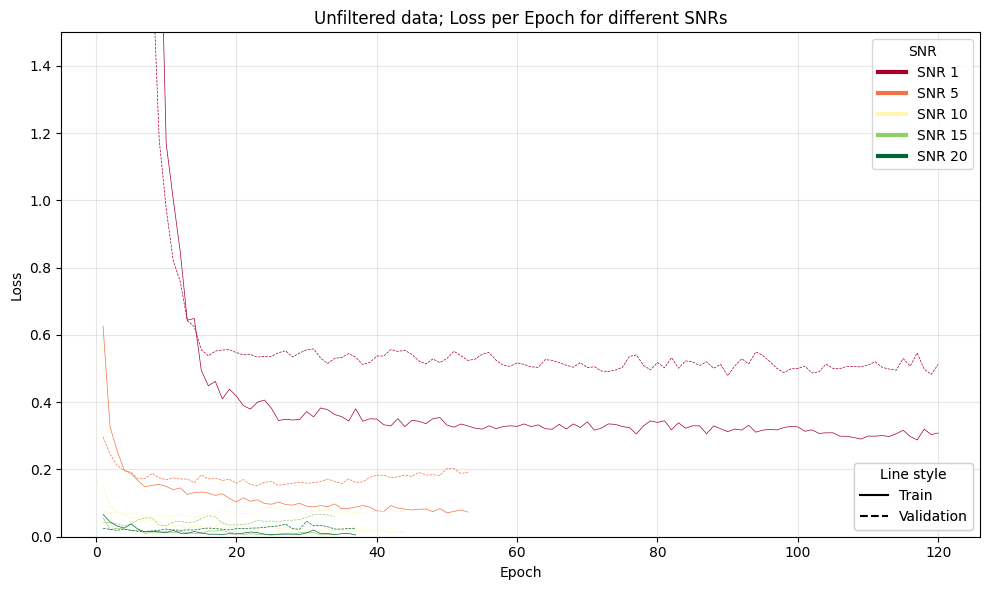

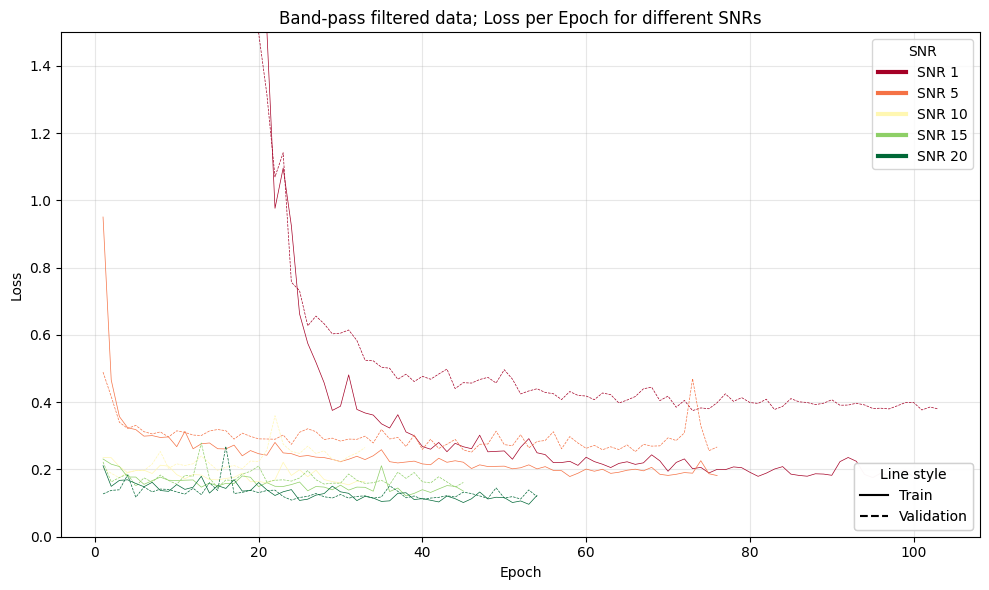

In [46]:
# Part 2: Multi channels

# Load unfiltered data
importlib.reload(settings) 
importlib.reload(kp)
 
X_embeddings_snr1_2, y_snr1_2 = get_data_from_dict(settings.data_pair2_snr1_2, base_model, force_reload=True)
X_embeddings_snr5_7, y_snr5_7 = get_data_from_dict(settings.data_pair2_snr5_7, base_model, force_reload=True)
X_embeddings_snr10_12, y_snr10_12 = get_data_from_dict(settings.data_pair2_snr10_12, base_model, force_reload=True)
X_embeddings_snr15_17, y_snr15_17 = get_data_from_dict(settings.data_pair2_snr15_17, base_model, force_reload=True)
X_embeddings_snr20_23, y_snr20_23 = get_data_from_dict(settings.data_pair2_snr20_23, base_model, force_reload=True)


# Load ICA filtered data
X_embeddings_snr1_2_ica, y_snr1_2_ica = get_data_from_dict(settings.data_pair2_snr1_2, base_model, force_reload= True, apply_filter="ica")
X_embeddings_snr5_7_ica, y_snr5_7_ica = get_data_from_dict(settings.data_pair2_snr5_7, base_model, force_reload= True, apply_filter="ica")
X_embeddings_snr10_12_ica, y_snr10_12_ica = get_data_from_dict(settings.data_pair2_snr10_12, base_model, force_reload= True, apply_filter="ica")
X_embeddings_snr15_17_ica, y_snr15_17_ica = get_data_from_dict(settings.data_pair2_snr15_17, base_model, force_reload= True, apply_filter="ica")
X_embeddings_snr20_23_ica, y_snr20_23_ica = get_data_from_dict(settings.data_pair2_snr20_23, base_model, force_reload= True, apply_filter="ica")

# Train on unfiltered data
_, train_losses1_2, val_losses1_2 = train_model(X_embeddings_snr1_2, y_snr1_2, model, device, title= f'SNR 1 & 2', save=False)
_, train_losses5_7, val_losses5_7 = train_model(X_embeddings_snr5_7, y_snr5_7, model, device, title= f'SNR 5 & 7', save=False)
_, train_losses10_12, val_losses10_12 = train_model(X_embeddings_snr10_12, y_snr10_12, model, device, title= f'SNR 10 & 12', save=False)
_, train_losses15_17, val_losses15_17 = train_model(X_embeddings_snr15_17, y_snr15_17, model, device, title= f'SNR 15 & 17', save=False)
_, train_losses20_23, val_losses20_23 = train_model(X_embeddings_snr20_23, y_snr20_23, model, device, title= f'SNR 20 & 23', save=False)

# Train on ica filtered data
_, train_losses1_ica, val_losses1_ica = train_model(X_embeddings_snr1_2_ica, y_snr1_2_ica, model, device, title= f'SNR 1 & 2', save=False)
_, train_losses5_ica, val_losses5_ica = train_model(X_embeddings_snr5_7_ica, y_snr5_7_ica, model, device, title= f'SNR 5 & 7', save=False)
_, train_losses10_ica, val_losses10_ica = train_model(X_embeddings_snr10_12_ica, y_snr10_12_ica, model, device, title= f'SNR 10 & 12', save=False)
_, train_losses15_ica, val_losses15_ica = train_model(X_embeddings_snr15_17_ica, y_snr15_17_ica, model, device, title= f'SNR 15 & 17', save=False)
_, train_losses20_ica, val_losses20_ica = train_model(X_embeddings_snr20_23_ica, y_snr20_23_ica, model, device, title= f'SNR 20 & 23', save=False)


unfiltered_losses_by_snr = {
    1:  (train_losses1_2,  val_losses1_2),
    5: (train_losses5_7, val_losses5_7),
    10: (train_losses10_12, val_losses10_12),
    15: (train_losses15_17, val_losses15_17),
    20:  (train_losses20_23,  val_losses20_23)
}

filtered_losses_by_snr = {
    1:  (train_losses1_ica,  val_losses1_ica),
    5: (train_losses5_ica, val_losses5_ica),
    10: (train_losses10_ica, val_losses10_ica),
    15: (train_losses15_ica, val_losses15_ica),
    20:  (train_losses20_ica,  val_losses20_ica)
}

plot_losses_discrete(unfiltered_losses_by_snr, title="Unfiltered data; Loss per Epoch for different SNRs", save_path="history/loss_multichannel.pdf", max_epochs=300, y_lim=1.5)
plot_losses_discrete(filtered_losses_by_snr, title="Band-pass filtered data; Loss per Epoch for different SNRs", save_path="history/loss_ica.pdf", max_epochs=300, y_lim=1.5)

In [ ]:
# Test and evaluate the model

model.eval()
X_test_tensor = torch.tensor(X_embeddings_test, dtype=torch.float32).to(device)
with torch.no_grad():
    y_pred_test = model(X_test_tensor).cpu().numpy()
y_pred_test = postprocess_output(y_pred_test)  # If needed

X_env_tensor = torch.tensor(X_embeddings_env, dtype=torch.float32).to(device)
with torch.no_grad():
    y_pred_env = model(X_env_tensor).cpu().numpy()
y_pred_env = postprocess_output(y_pred_env)

event_metrics = EventBasedMetrics(event_label_list=settings.CLASS_NAMES, t_collar=params.PATCH_WINDOW_SECONDS)
segment_metrics = SegmentBasedMetrics(event_label_list=settings.CLASS_NAMES, time_resolution=params.PATCH_WINDOW_SECONDS)

predicted_event_list_test = predictions_to_event_list(y_pred_test)
reference_event_list_test = predictions_to_event_list(y_test)
predicted_event_list_env = predictions_to_event_list(y_pred_env)
reference_event_list_env = predictions_to_event_list(y_env)
print("Data processed for evaluation...")
print("Predicted event list test length:", len(predicted_event_list_test))
print("Reference event list test length:", len(reference_event_list_test))
print("Predicted event list env length:", len(predicted_event_list_env))
print("Reference event list env length:", len(reference_event_list_env))

event_metrics.evaluate(predicted_event_list_test, reference_event_list_test)
segment_metrics.evaluate(predicted_event_list_test, reference_event_list_test)

save_sed_metric('Event-based-dataset', event_metrics.results(), timestr)
save_sed_metric('Segment-based-dataset', segment_metrics.results(), timestr)
print_metrics(event_metrics.results(), "Event-based (Test set)")
print_metrics(segment_metrics.results(), "Segment-based (Test set)")

event_metrics.evaluate(predicted_event_list_env, reference_event_list_env)
segment_metrics.evaluate(predicted_event_list_env, reference_event_list_env)

save_sed_metric('Event-based-env-dataset', event_metrics.results(), timestr)
save_sed_metric('Segment-based-env-dataset', segment_metrics.results(), timestr)
print_metrics(event_metrics.results(), "Event-based (Environment set)")
print_metrics(segment_metrics.results(), "Segment-based (Environment set)")

Data processed for evaluation...
Predicted event list test length: 23856
Reference event list test length: 32488
Predicted event list env length: 41910
Reference event list env length: 76002


KeyboardInterrupt: 

In [ ]:
# Load metrics if desired

event_metric = load_sed_metric(f'history/251104-162942/Event-based-env-dataset.pk1')
segment_metric = load_sed_metric(f'history/251104-162942/Segment-based-env-dataset.pk1')

print_metrics(event_metrics.results(), "Event-based (Env set)")
print_metrics(segment_metrics.results(), "Segment-based (Env set)")


FileNotFoundError: [Errno 2] No such file or directory: 'history/251104-162942/Event-based-env-dataset.pk1'

In [ ]:
# Old script for training, made into fucntion train_model()

""" # Prepare PyTorch datasets and loaders
    X_train_tensor = torch.tensor(X_embeddings_train, dtype=torch.float32).to(device)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32).to(device)
    print("y_train_tensor shape:", y_train_tensor.shape)
    train_dataset = torch.utils.data.TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)

    # Validation split
    val_split = getattr(settings, "VAL_SIZE", 0.2)
    num_val = int(len(X_train_tensor) * val_split)
    indices = np.arange(len(X_train_tensor.cpu()))
    np.random.shuffle(indices)
    val_indices = indices[:num_val]
    train_indices = indices[num_val:]
    X_val_tensor = X_train_tensor[val_indices]
    y_val_tensor = y_train_tensor[val_indices]
    val_dataset = torch.utils.data.TensorDataset(X_val_tensor, y_val_tensor)
    val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=64, shuffle=False)

    #criterion = nn.BCELoss()
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    num_epochs = 300
    patience = 20
    best_loss = float('inf')
    epochs_no_improve = 0
    best_state = None
    train_losses, val_losses = [], []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for inputs, targets in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
        epoch_loss = running_loss / len(train_loader.dataset)
        train_losses.append(epoch_loss)

        # Validation
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for inputs, targets in val_loader:
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                val_loss += loss.item() * inputs.size(0)
        val_loss /= len(val_loader.dataset)
        val_losses.append(val_loss)
        print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {epoch_loss:.4f} | Val Loss: {val_loss:.4f}")

        # Early stopping
        if val_loss < best_loss:
            best_loss = val_loss
            best_state = model.state_dict()
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print("Early stopping triggered.")
                break

    model.load_state_dict(best_state)

    # SAVE MODEL 
    timestr = time.strftime("%Y%m%d-%H%M%S")
    os.makedirs('history', exist_ok=True)
    os.makedirs(f'history/{timestr}', exist_ok=True)
    torch.save(model, f'history/{timestr}/modified_model.pt')

    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.legend()
    plt.show()
    pdf_path = f'history/{timestr}/loss_plot.pdf'
    plt.savefig(pdf_path, format='pdf', bbox_inches='tight')
    print(f'Saved vector PDF: {pdf_path}') """